<a href="https://colab.research.google.com/github/singhm8755/7150CEM-Ecommerce-Returns-CLV/blob/main/3_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Mounted at /content/drive
Loading dataset...
Dataset loaded: 120,000 transactions, 12,000 customers

SECTION 1: DATASET OVERVIEW

Dataset Shape: (120000, 14)

Column Data Types:
transaction_id            int64
customer_id               int64
transaction_date         object
product_category         object
payment_method           object
device_type              object
customer_segment         object
customer_tenure_days      int64
order_frequency_12m       int64
order_value_gbp         float64
click_depth               int64
time_on_page_seconds      int64
product_page_visits       int64
returned                  int64
dtype: object

First 10 rows:
   transaction_id  customer_id transaction_date product_category  \
0           93666          567       2024-01-01      Home_Garden   
1           68309         8327       2024-01-01      Electronics   
2          106907         7450       2024-01-01      Home_Garden   
3           87602         7738       2024-01-01          Fashion   
4   

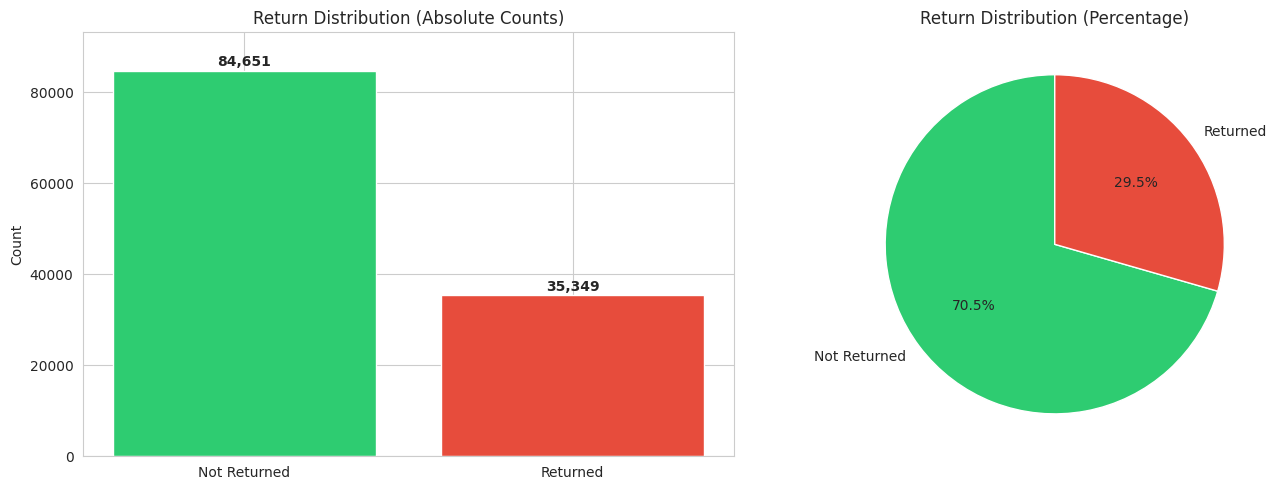

Saved: 01_target_distribution.png

SECTION 3: CATEGORICAL FEATURE ANALYSIS



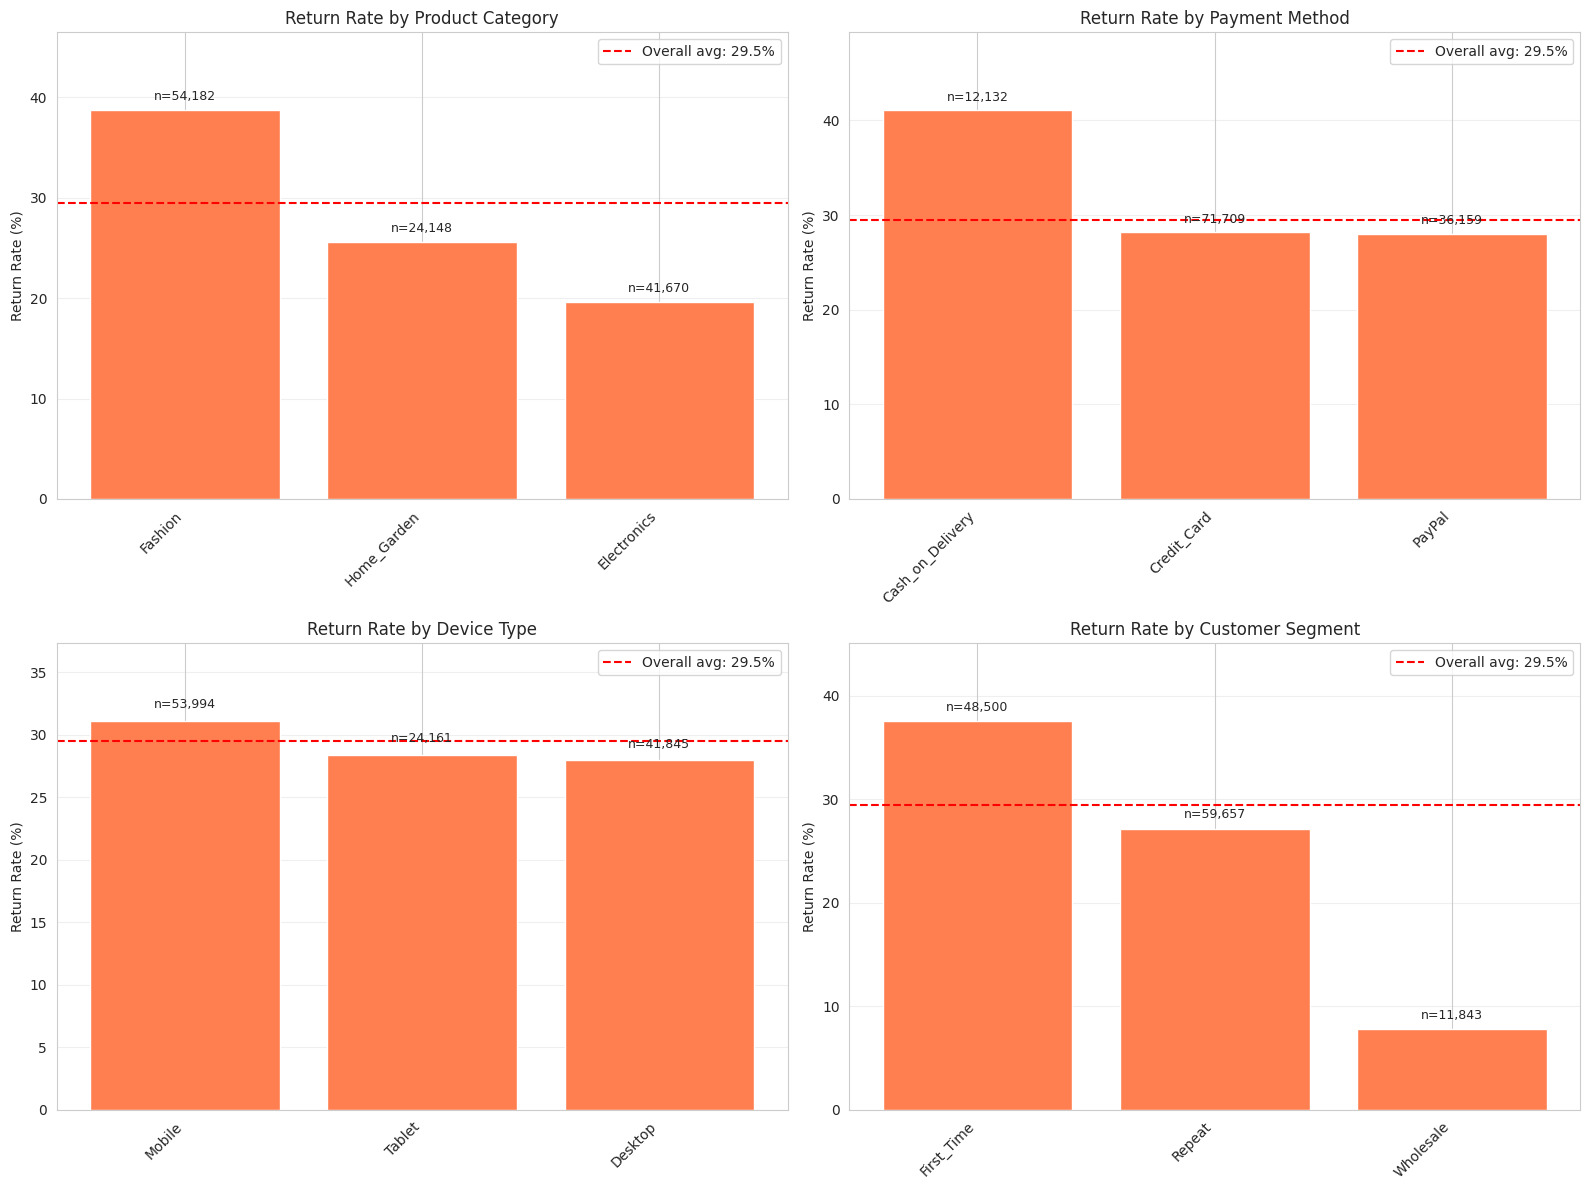

Saved: 02_categorical_analysis.png


PRODUCT_CATEGORY Return Rates:
--------------------------------------------------
                 Return_Rate  Count
product_category                   
Fashion                38.7%  54182
Home_Garden            25.6%  24148
Electronics            19.6%  41670

PAYMENT_METHOD Return Rates:
--------------------------------------------------
                 Return_Rate  Count
payment_method                     
Cash_on_Delivery       41.1%  12132
Credit_Card            28.2%  71709
PayPal                 28.0%  36159

DEVICE_TYPE Return Rates:
--------------------------------------------------
            Return_Rate  Count
device_type                   
Mobile            31.1%  53994
Tablet            28.4%  24161
Desktop           28.0%  41845

CUSTOMER_SEGMENT Return Rates:
--------------------------------------------------
                 Return_Rate  Count
customer_segment                   
First_Time             37.6%  48500
Repeat          

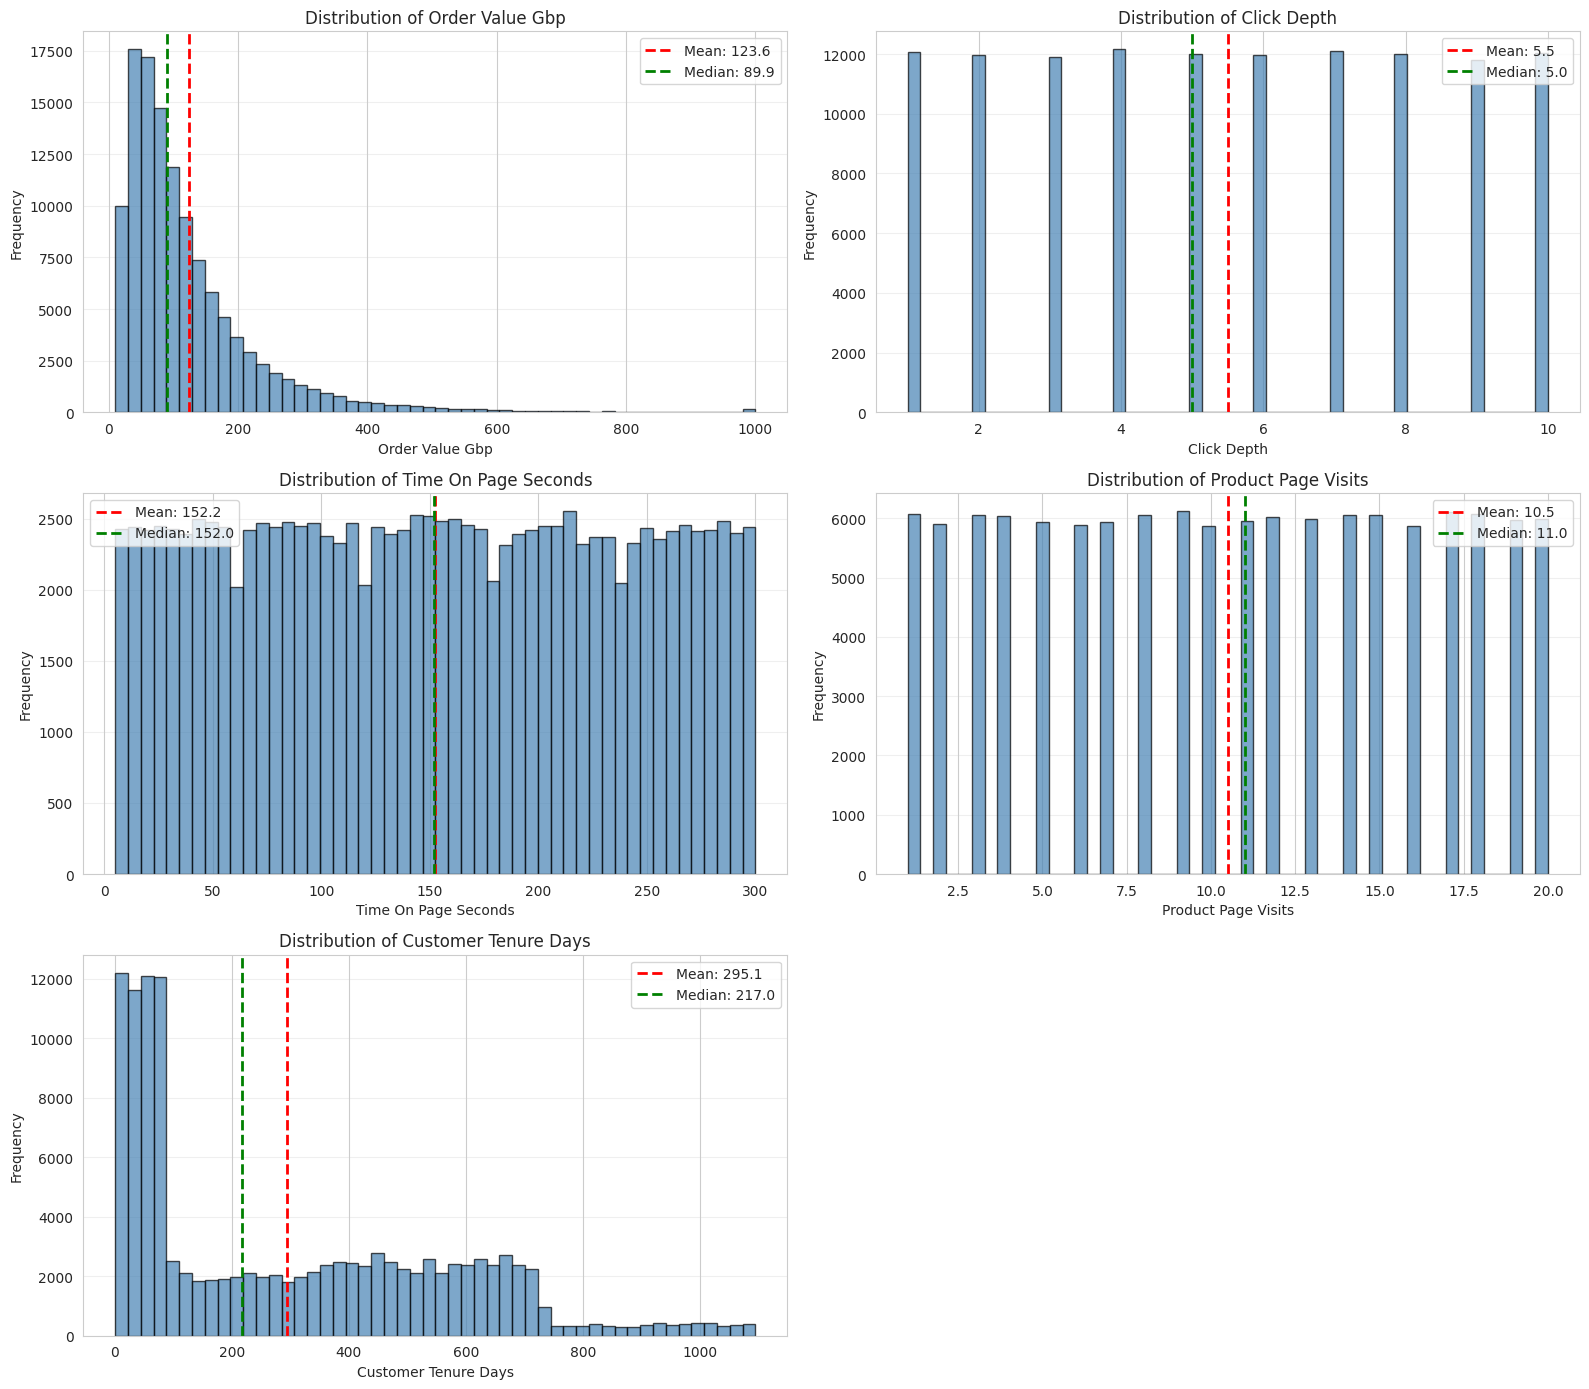

Saved: 03_numeric_distributions.png

SECTION 5: RETURNED VS NOT RETURNED COMPARISON



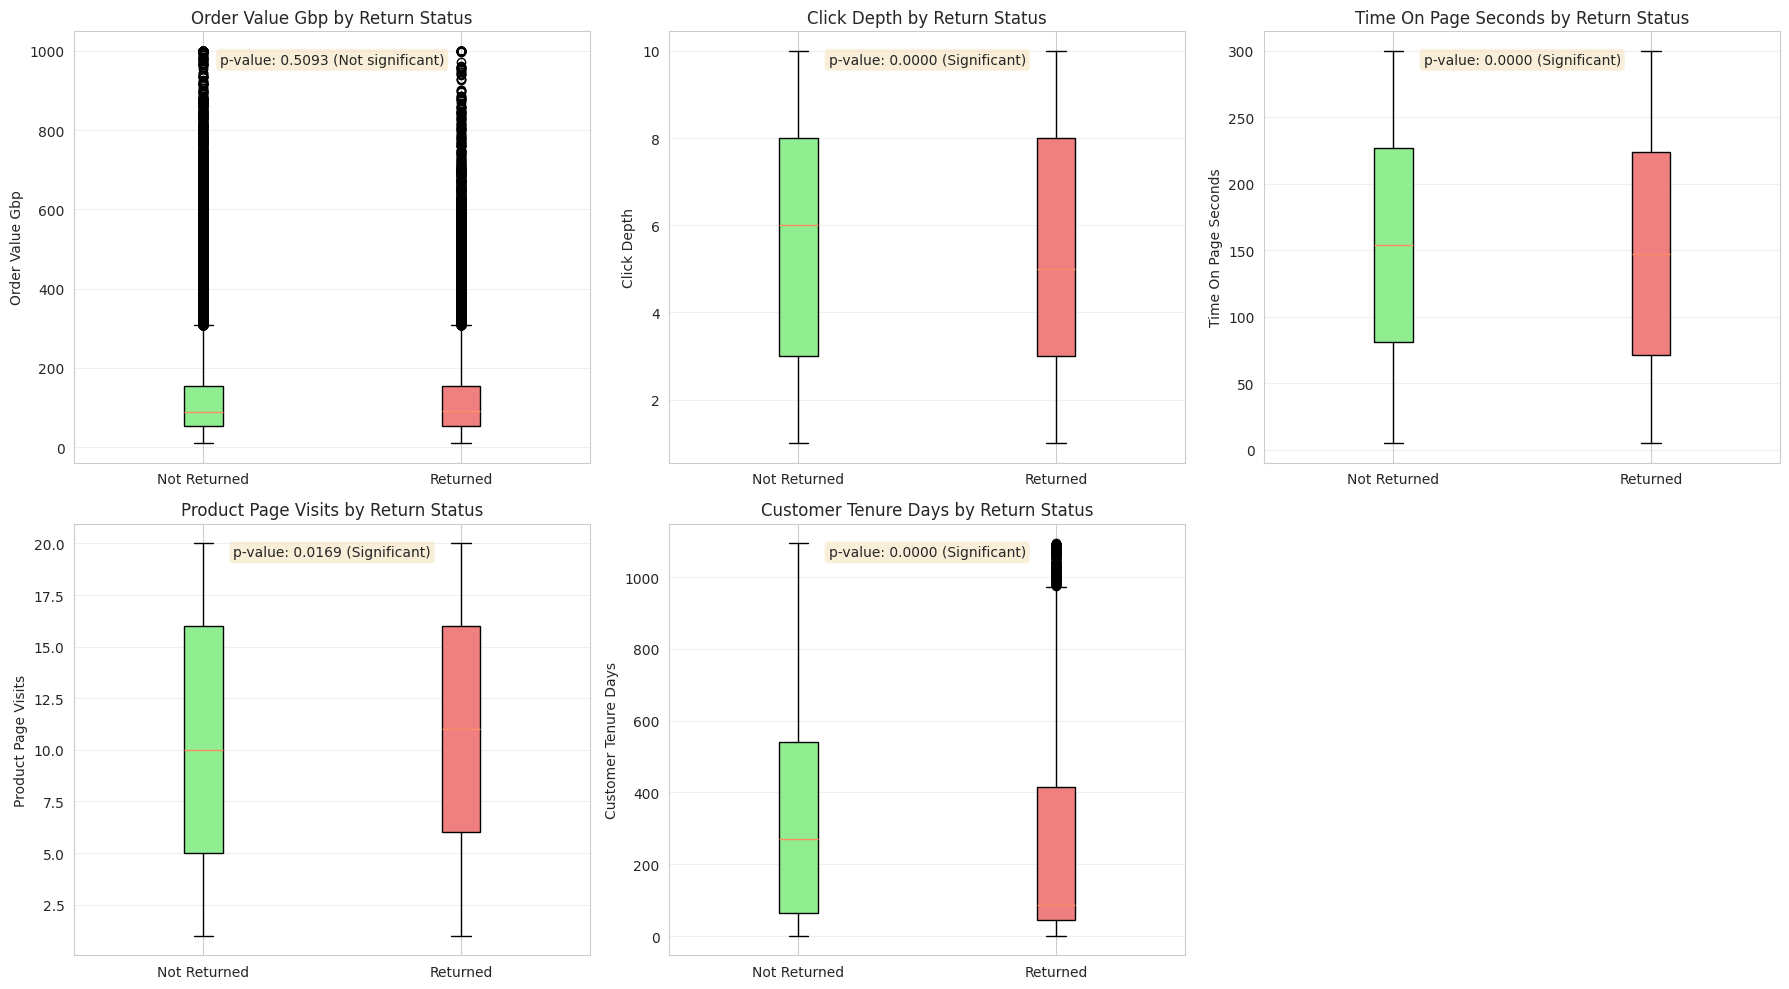

Saved: 04_returned_comparison.png


Summary Statistics by Return Status:

ORDER_VALUE_GBP:
--------------------------------------------------
                mean    50%         std
returned                               
0         123.592735  89.76  113.728379
1         123.704060  90.45  113.310973

CLICK_DEPTH:
--------------------------------------------------
              mean  50%       std
returned                         
0         5.573508  6.0  2.849427
1         5.310956  5.0  2.914039

TIME_ON_PAGE_SECONDS:
--------------------------------------------------
                mean    50%      std
returned                            
0         153.674133  154.0  84.7962
1         148.635067  147.0  86.6904

PRODUCT_PAGE_VISITS:
--------------------------------------------------
               mean   50%       std
returned                           
0         10.481625  10.0  5.776108
1         10.568899  11.0  5.751767

CUSTOMER_TENURE_DAYS:
-----------------------------------

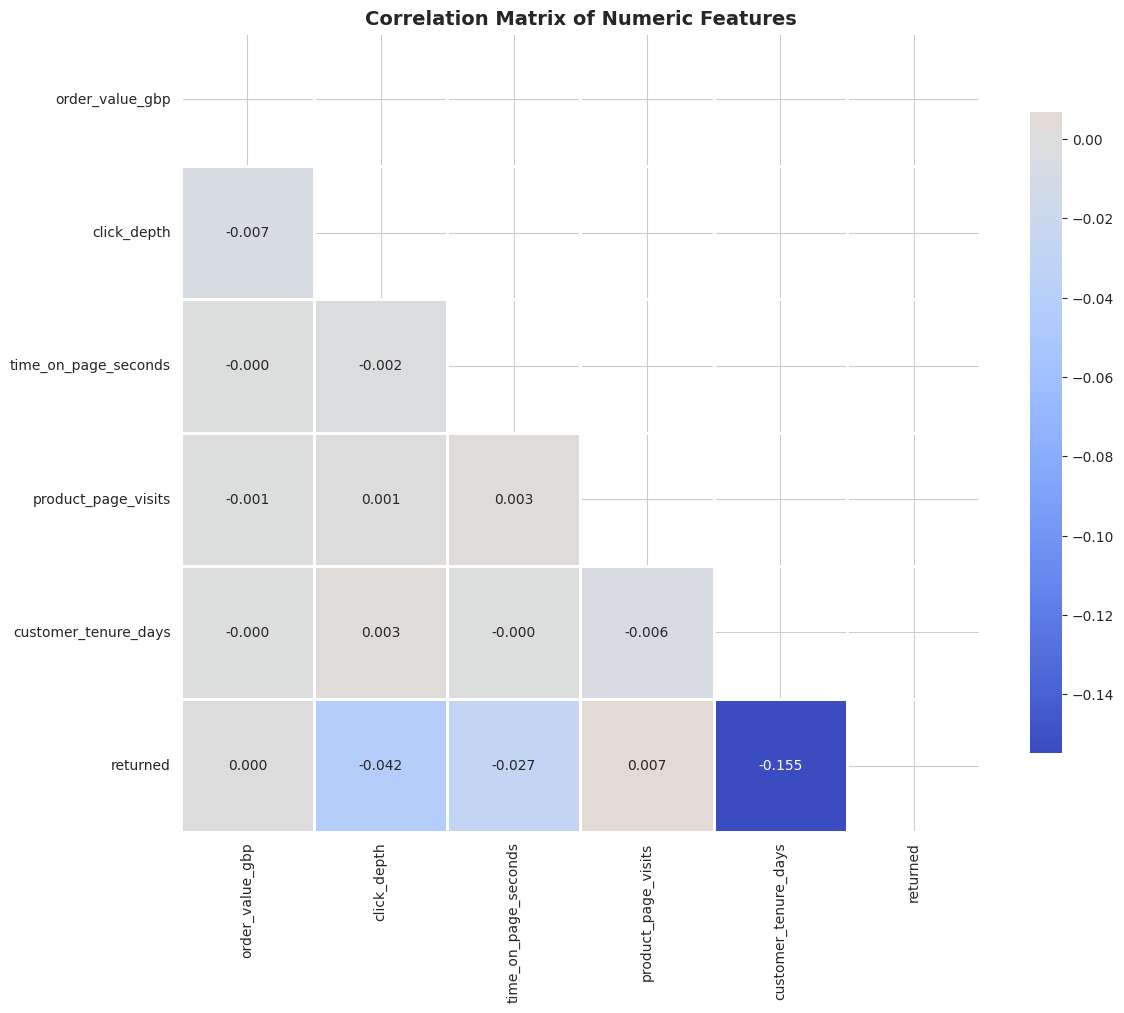

Saved: 05_correlation_matrix.png

Feature Correlations with Return Outcome:
--------------------------------------------------
product_page_visits           : +0.0069
order_value_gbp               : +0.0004
time_on_page_seconds          : -0.0269
click_depth                   : -0.0417
customer_tenure_days          : -0.1549

SECTION 7: MULTI-DIMENSIONAL ANALYSIS



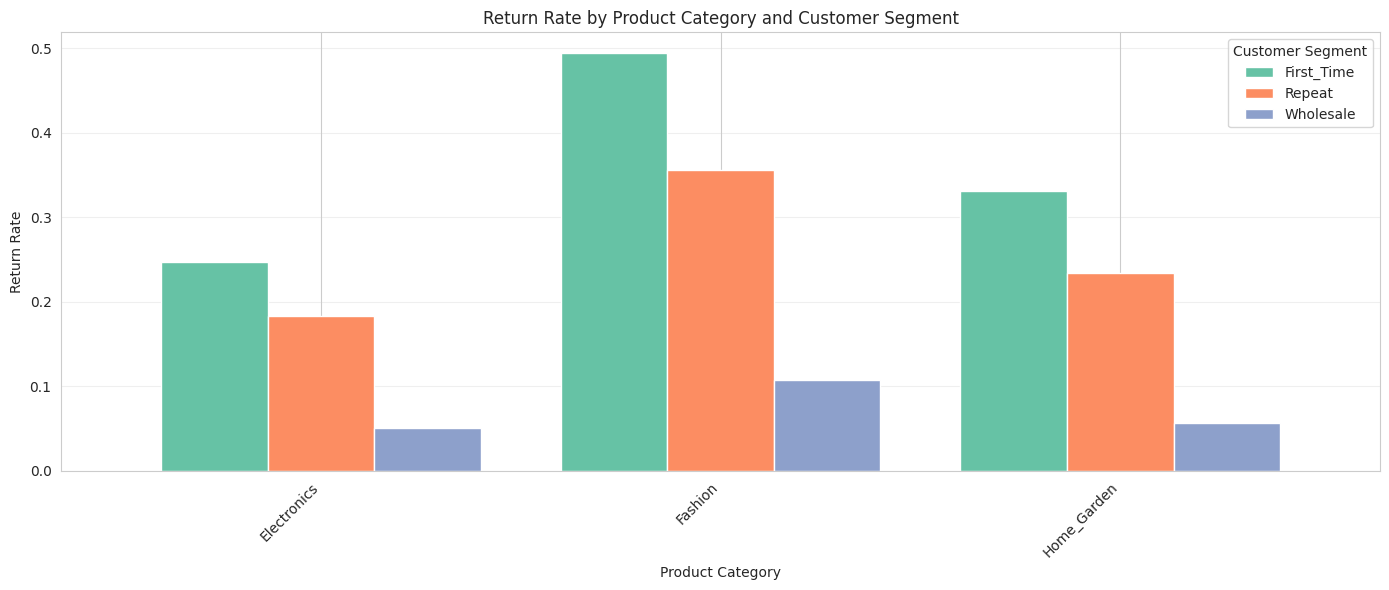

Saved: 06_category_segment_interaction.png

SECTION 8: KEY INSIGHTS SUMMARY

1. Overall return rate: 29.5%
2. Highest return category: Fashion (38.7%)
3. Cash on Delivery return rate (41.1%) is 1.46x higher than Credit Card (28.2%)
4. First-time buyers have 4.8x higher return rate than wholesale customers
5. Customer tenure shows 0.155 negative correlation with returns

EDA COMPLETE - Ready for Model Training

All visualizations saved to:
/content/drive/MyDrive/7150CEM_Project/outputs/


In [ ]:
# Exploratory Data Analysis for E-commerce Return Risk Dataset
# This notebook performs comprehensive exploratory analysis to understand
# patterns in customer behavior, transactions, and return outcomes.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Configure visualization settings
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Loading dataset...")
df = pd.read_csv('/content/drive/MyDrive/7150CEM_Project/data/synthetic_ecommerce.csv')
print(f"Dataset loaded: {len(df):,} transactions, {df['customer_id'].nunique():,} customers")
print()

# ============================================================================
# Section 1: Dataset Overview
# ============================================================================

print("=" * 70)
print("SECTION 1: DATASET OVERVIEW")
print("=" * 70)
print()

print("Dataset Shape:", df.shape)
print()

print("Column Data Types:")
print(df.dtypes)
print()

print("First 10 rows:")
print(df.head(10))
print()

# ============================================================================
# Section 2: Target Variable Analysis
# ============================================================================

print("=" * 70)
print("SECTION 2: TARGET VARIABLE ANALYSIS (RETURNED)")
print("=" * 70)
print()

# Overall distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
return_counts = df['returned'].value_counts()
axes[0].bar(['Not Returned', 'Returned'], return_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count')
axes[0].set_title('Return Distribution (Absolute Counts)')
axes[0].set_ylim(0, max(return_counts.values) * 1.1)
for i, v in enumerate(return_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(return_counts.values, labels=['Not Returned', 'Returned'], autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Return Distribution (Percentage)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 01_target_distribution.png")
print()

# ============================================================================
# Section 3: Categorical Feature Analysis
# ============================================================================

print("=" * 70)
print("SECTION 3: CATEGORICAL FEATURE ANALYSIS")
print("=" * 70)
print()

categorical_features = ['product_category', 'payment_method', 'device_type', 'customer_segment']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    # Calculate return rate by category
    return_by_cat = df.groupby(feature)['returned'].agg(['mean', 'count']).reset_index()
    return_by_cat.columns = [feature, 'return_rate', 'count']
    return_by_cat = return_by_cat.sort_values('return_rate', ascending=False)

    # Create grouped bar chart
    x_pos = np.arange(len(return_by_cat))
    bars = axes[idx].bar(x_pos, return_by_cat['return_rate'] * 100, color='coral')

    # Add count labels on bars
    for i, (rate, count) in enumerate(zip(return_by_cat['return_rate'], return_by_cat['count'])):
        axes[idx].text(i, rate * 100 + 1, f'n={count:,}', ha='center', fontsize=9)

    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(return_by_cat[feature], rotation=45, ha='right')
    axes[idx].set_ylabel('Return Rate (%)')
    axes[idx].set_title(f'Return Rate by {feature.replace("_", " ").title()}')
    axes[idx].set_ylim(0, max(return_by_cat['return_rate']) * 120)
    axes[idx].axhline(df['returned'].mean() * 100, color='red', linestyle='--',
                      label=f'Overall avg: {df["returned"].mean()*100:.1f}%')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/02_categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 02_categorical_analysis.png")
print()

# Print statistics
for feature in categorical_features:
    print(f"\n{feature.upper()} Return Rates:")
    print("-" * 50)
    stats_df = df.groupby(feature)['returned'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    stats_df.columns = ['Return_Rate', 'Count']
    stats_df['Return_Rate'] = stats_df['Return_Rate'].apply(lambda x: f'{x*100:.1f}%')
    print(stats_df)

print()

# ============================================================================
# Section 4: Numerical Feature Distributions
# ============================================================================

print("=" * 70)
print("SECTION 4: NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 70)
print()

numeric_features = ['order_value_gbp', 'click_depth', 'time_on_page_seconds',
                   'product_page_visits', 'customer_tenure_days']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    # Histogram with KDE
    axes[idx].hist(df[feature], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel(feature.replace('_', ' ').title())
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature.replace("_", " ").title()}')

    # Add mean and median lines
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/03_numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 03_numeric_distributions.png")
print()

# ============================================================================
# Section 5: Returned vs Not Returned Comparison
# ============================================================================

print("=" * 70)
print("SECTION 5: RETURNED VS NOT RETURNED COMPARISON")
print("=" * 70)
print()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    # Box plot comparing returned vs not returned
    data_to_plot = [df[df['returned'] == 0][feature], df[df['returned'] == 1][feature]]
    bp = axes[idx].boxplot(data_to_plot, labels=['Not Returned', 'Returned'], patch_artist=True)

    # Color the boxes
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightcoral']):
        patch.set_facecolor(color)

    axes[idx].set_ylabel(feature.replace('_', ' ').title())
    axes[idx].set_title(f'{feature.replace("_", " ").title()} by Return Status')
    axes[idx].grid(axis='y', alpha=0.3)

    # Add statistical test
    stat, pval = stats.mannwhitneyu(
        df[df['returned'] == 0][feature],
        df[df['returned'] == 1][feature]
    )
    sig_text = 'Significant' if pval < 0.05 else 'Not significant'
    axes[idx].text(0.5, 0.95, f'p-value: {pval:.4f} ({sig_text})',
                  transform=axes[idx].transAxes, ha='center', va='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/04_returned_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 04_returned_comparison.png")
print()

# Print summary statistics
print("\nSummary Statistics by Return Status:")
print("=" * 70)
for feature in numeric_features:
    print(f"\n{feature.upper()}:")
    print("-" * 50)
    print(df.groupby('returned')[feature].describe()[['mean', '50%', 'std']])

print()

# ============================================================================
# Section 6: Correlation Analysis
# ============================================================================

print("=" * 70)
print("SECTION 6: CORRELATION ANALYSIS")
print("=" * 70)
print()

# Select numeric columns for correlation
corr_features = numeric_features + ['returned']
corr_matrix = df[corr_features].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/05_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 05_correlation_matrix.png")
print()

# Print correlations with target variable
print("Feature Correlations with Return Outcome:")
print("-" * 50)
target_corr = corr_matrix['returned'].drop('returned').sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"{feature:30s}: {corr:+.4f}")

print()

# ============================================================================
# Section 7: Multi-dimensional Analysis
# ============================================================================

print("=" * 70)
print("SECTION 7: MULTI-DIMENSIONAL ANALYSIS")
print("=" * 70)
print()

# Category + Segment interaction
fig, ax = plt.subplots(figsize=(14, 6))
pivot_data = df.groupby(['product_category', 'customer_segment'])['returned'].mean().unstack()
pivot_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Return Rate')
ax.set_xlabel('Product Category')
ax.set_title('Return Rate by Product Category and Customer Segment')
ax.legend(title='Customer Segment')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/7150CEM_Project/outputs/06_category_segment_interaction.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 06_category_segment_interaction.png")
print()

# ============================================================================
# Section 8: Key Insights Summary
# ============================================================================

print("=" * 70)
print("SECTION 8: KEY INSIGHTS SUMMARY")
print("=" * 70)
print()

insights = []

# Insight 1: Overall return rate
overall_return = df['returned'].mean()
insights.append(f"1. Overall return rate: {overall_return:.1%}")

# Insight 2: Category with highest returns
highest_cat = df.groupby('product_category')['returned'].mean().idxmax()
highest_rate = df.groupby('product_category')['returned'].mean().max()
insights.append(f"2. Highest return category: {highest_cat} ({highest_rate:.1%})")

# Insight 3: Payment method insight
cod_rate = df[df['payment_method'] == 'Cash_on_Delivery']['returned'].mean()
card_rate = df[df['payment_method'] == 'Credit_Card']['returned'].mean()
insights.append(f"3. Cash on Delivery return rate ({cod_rate:.1%}) is {cod_rate/card_rate:.2f}x higher than Credit Card ({card_rate:.1%})")

# Insight 4: Customer segment insight
first_time_rate = df[df['customer_segment'] == 'First_Time']['returned'].mean()
wholesale_rate = df[df['customer_segment'] == 'Wholesale']['returned'].mean()
insights.append(f"4. First-time buyers have {first_time_rate/wholesale_rate:.1f}x higher return rate than wholesale customers")

# Insight 5: Tenure correlation
tenure_corr = corr_matrix.loc['customer_tenure_days', 'returned']
insights.append(f"5. Customer tenure shows {abs(tenure_corr):.3f} negative correlation with returns")

for insight in insights:
    print(insight)

print()
print("=" * 70)
print("EDA COMPLETE - Ready for Model Training")
print("=" * 70)
print()
print("All visualizations saved to:")
print("/content/drive/MyDrive/7150CEM_Project/outputs/")
